In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from chemevo import evolution as evo
import astropy
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

colors = ["#0072B2", "#E69F00", "#009E73", "#D55E00", "#CC79A7", "#F0E442"]
linestyles = ['-', '--', ':', '-.']

In [3]:
import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [4]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

highalpha = pd.read_csv("../highalpha.csv")
lowalpha = pd.read_csv("../lowalpha.csv")

data = fitsrec_to_pandas(astronn_data)

data['MN_O'] = data['MN_H'] - data['O_H']
data['FE_O'] = data['FE_H'] - data['O_H']
data['MN_MG'] = data['MN_H'] - data['MG_H']
data['FE_MG'] = data['FE_H'] - data['MG_H']
data['MG_FE'] = data['MG_H'] - data['FE_H']
data['MN_FE'] = data['MN_H'] - data['FE_H']

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])

# Create FE_H range arrays
feh_neg = np.linspace(data['FE_H'].min(), 0, 300)  # negative metallicity
feh_pos = np.linspace(0, data['FE_H'].max(), 300)  # positive metallicity

# Compute boundary line
mgfe_neg = 0.12 - 0.13 * feh_neg        # sloped part
mgfe_pos = np.full_like(feh_pos, 0.12)  # flat part at +0.12
feh_line = np.concatenate([feh_neg, feh_pos])
mgfe_line = np.concatenate([mgfe_neg, mgfe_pos])
mgh_line = mgfe_line + feh_line
femg_line = feh_line - mgh_line

data_low_alpha = data_low_alpha[(data_low_alpha['galz'] < 2) & (data_low_alpha['galz'] > -2) &
                                (data_low_alpha['galr'] < 15) & (data_low_alpha['galr'] > 3)]

data_high_alpha = data_high_alpha[(data_high_alpha['galz'] < 2) & (data_high_alpha['galz'] > -2) &
                                (data_high_alpha['galr'] < 15) & (data_high_alpha['galr'] > 3)]

mnmg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
mnmg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='MN_MG', n_bins=20)
femg_high = compute_binned_median(data_high_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)
femg_low = compute_binned_median(data_low_alpha, x_col='MG_H', y_col='FE_MG', n_bins=20)

mnmg_high = mnmg_high[mnmg_high['count'] >= 100]
mnmg_low  = mnmg_low[mnmg_low['count']  >= 100]
femg_high = femg_high[femg_high['count'] >= 100]
femg_low  = femg_low[femg_low['count']  >= 100]

data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data_all = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

data_all = data_all[data_all['zmax'] < 5]

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_49952/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_49952/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby(x_bin_labels).agg(
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_49952/3137802370.py:49: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the 

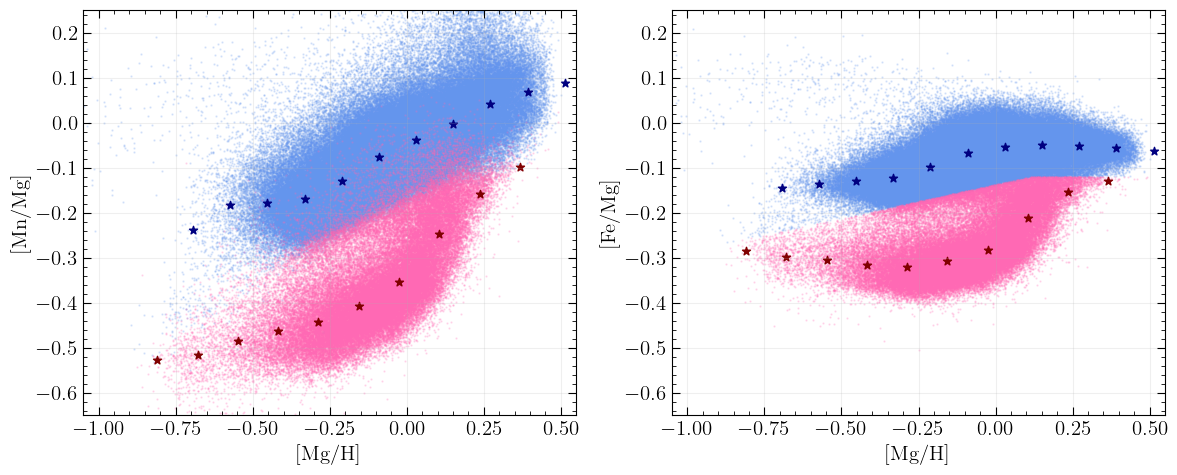

In [6]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.2, color = 'hotpink', s = 0.5)


plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.2, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.2, color = 'hotpink', s = 0.5)


plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

In [7]:
t_array = np.linspace(0.0001,14,int(1e3))
dt = t_array[1] - t_array[0]

def make_mock_pop(galaxy_model, sfr, n_samples=1000, error_on_met = 0.025, deltat=dt):
    mstars = sfr/galaxy_model.tau_star_arr[0] * deltat
    cdf_mstars = np.cumsum(mstars)/np.sum(mstars)
    u = np.random.rand(n_samples)
    sampled = np.searchsorted(cdf_mstars, u)
    gal_df = pd.DataFrame(columns=['O_H', 'Fe_O', 'Mn_O', 'O_Fe', 'Fe_H'])
    gal_df['O_H'] = np.random.normal(loc=galaxy_model.O_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_H'] = np.random.normal(loc=galaxy_model.Fe_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Mn_H'] = np.random.normal(loc=galaxy_model.Mn_H[sampled], scale = error_on_met, size=n_samples)
    gal_df['Fe_O'] = gal_df['Fe_H'] - gal_df['O_H']
    gal_df['Mn_O'] = gal_df['Mn_H'] - gal_df['O_H']
    gal_df['O_Fe'] = gal_df['O_H'] - gal_df['Fe_H']

    return gal_df

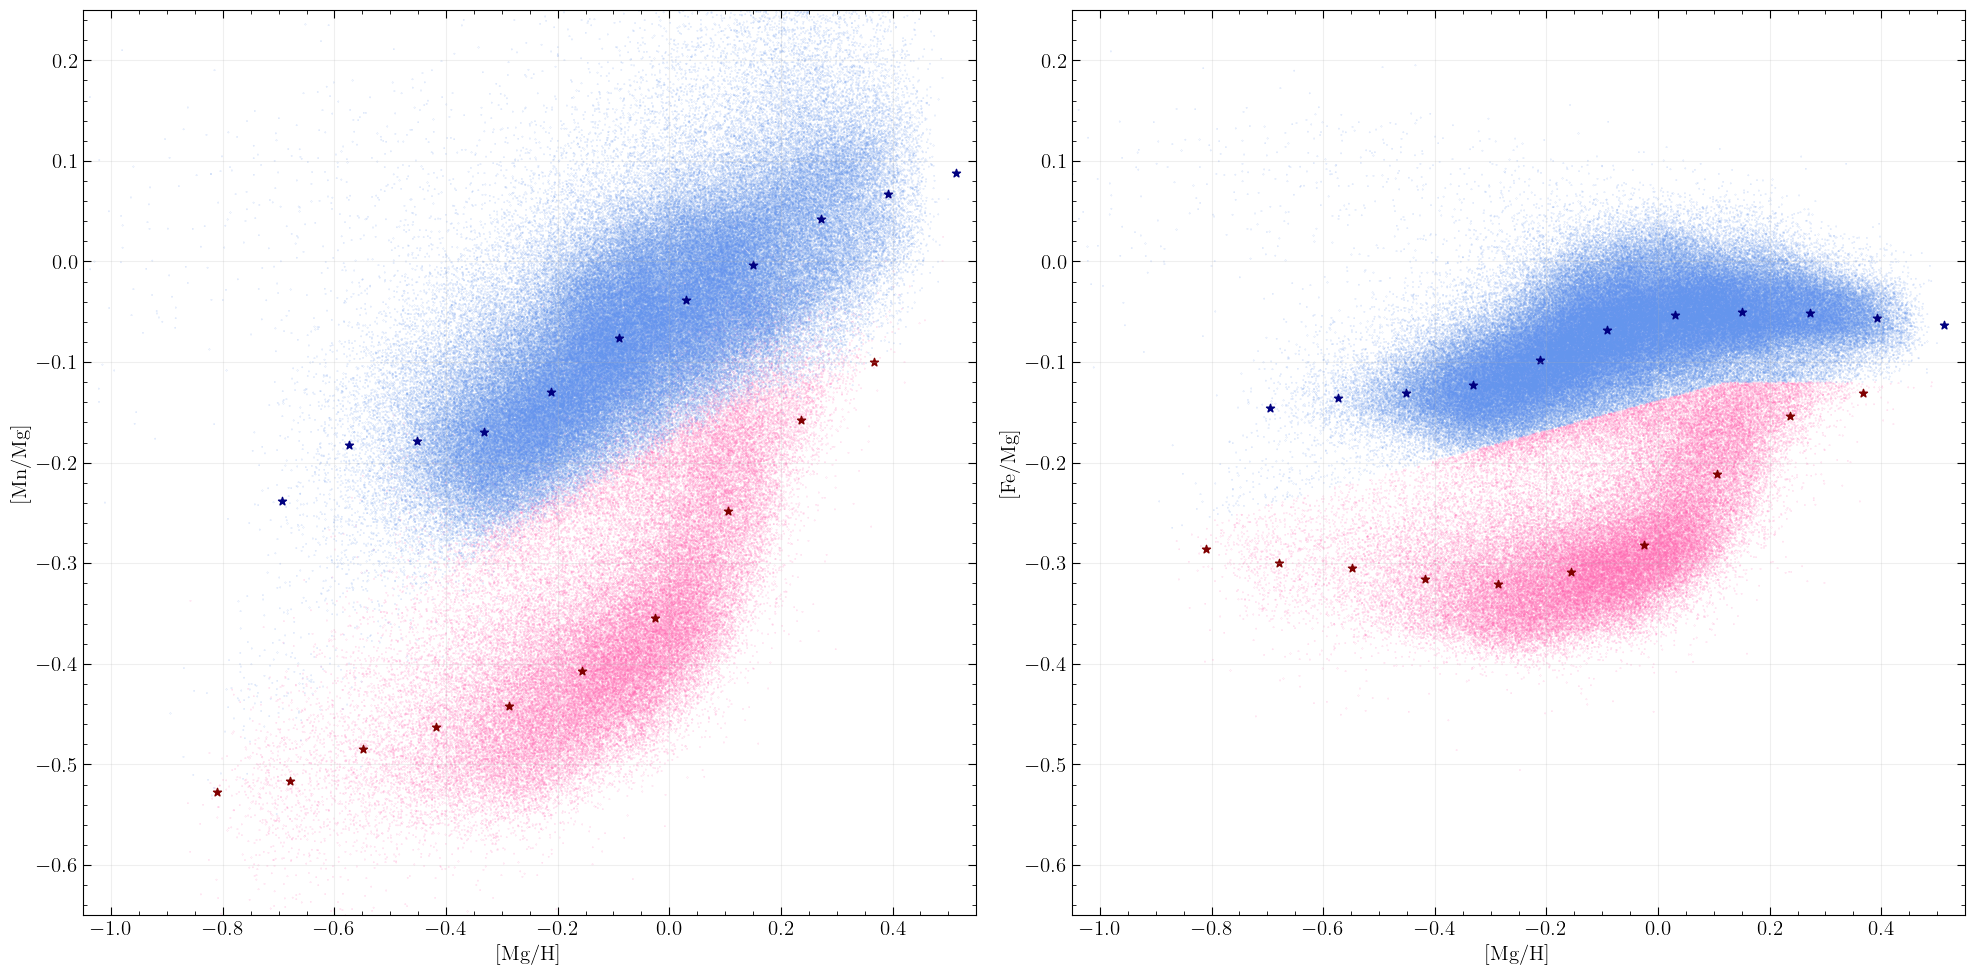

In [8]:
plt.figure(figsize=(20,10))
plt.subplot(1,2,1)
plt.scatter(data_all['MG_H'], data_all['MN_MG'], alpha = 0.9, color = data_all['color'], s = 0.01)


plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'navy')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)

plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_all['MG_H'], data_all['FE_MG'], alpha = 0.9, color = data_all['color'], s = 0.01)


plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'navy')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'maroon')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)
plt.tight_layout()

(-0.7, 0.5)

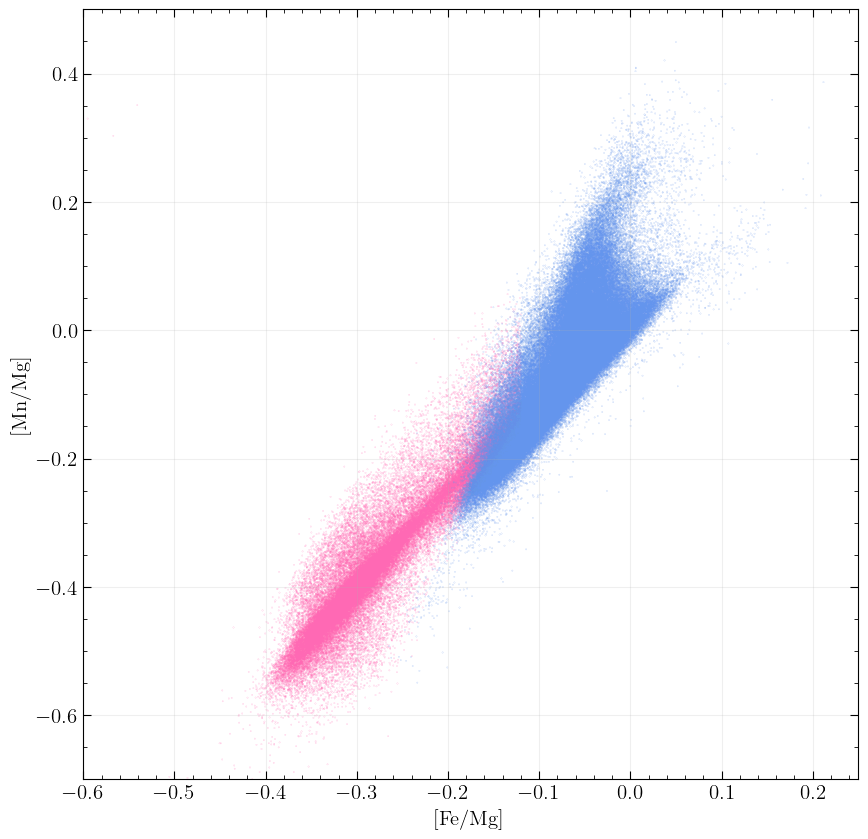

In [9]:
plt.figure(figsize=(10,10))

plt.scatter(data_all['FE_MG'], data_all['MN_MG'], s = 0.01, color = data_all['color'], alpha = 1)

'''
plt.plot([-0.5, 0.1], [-0.6 + 0.05, 0.2 + 0.05], color = 'black')
plt.plot([0.1, 0.1], [0.2, 0.4], color = 'black')
plt.plot([-0.15, -0.15], [-0.2, 0.4], color = 'black')
plt.plot([-0.15, 0.1], [0.4, 0.4], color = 'black')
'''


plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/Mg]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-0.60,0.25)
plt.ylim(-0.70,0.5)

In [10]:
def make_line(x, x1, x2, y1, y2):
    m = (y2 - y1) / (x2 - x1)
    return m * (x - x1) + y1

y_line = make_line(data_all['FE_MG'], -0.5, 0.1, -0.6 + 0.05, 0.2 + 0.05)

x_left  = -0.15
x_right =  0.10

fish_head_mask = (
    (data_all['FE_MG'] > x_left) &
    (data_all['FE_MG'] < x_right) &
    (data_all['MN_MG'] > y_line)
)

df_boxed = data_all[fish_head_mask]

(-0.7, 0.5)

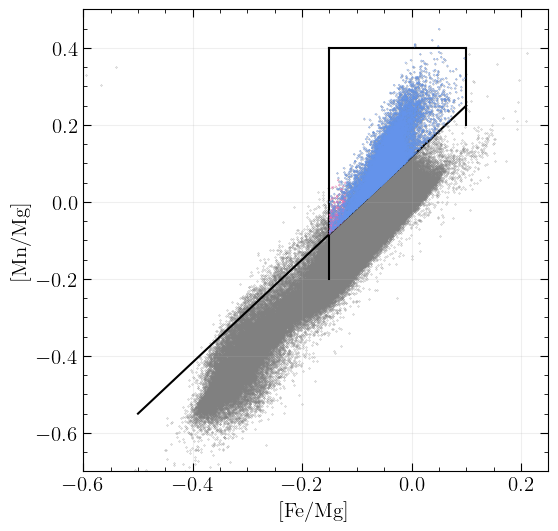

In [11]:
df_boxed = df_boxed[df_boxed['zmax'] < 10]
df_boxed = df_boxed[df_boxed['galr'] < 20]

plt.figure(figsize=(6,6))

plt.scatter(df_boxed['FE_MG'], df_boxed['MN_MG'], s = 0.05, color = df_boxed['color'], alpha = 1, zorder=5)
plt.scatter(data_all['FE_MG'], data_all['MN_MG'], s = 0.05, color = 'gray', alpha = 1)

plt.plot([-0.5, 0.1], [-0.6 + 0.05, 0.2 + 0.05], color = 'black')
plt.plot([0.1, 0.1], [0.2, 0.4], color = 'black')
plt.plot([-0.15, -0.15], [-0.2, 0.4], color = 'black')
plt.plot([-0.15, 0.1], [0.4, 0.4], color = 'black')

plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/Mg]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-0.60,0.25)
plt.ylim(-0.70,0.5)

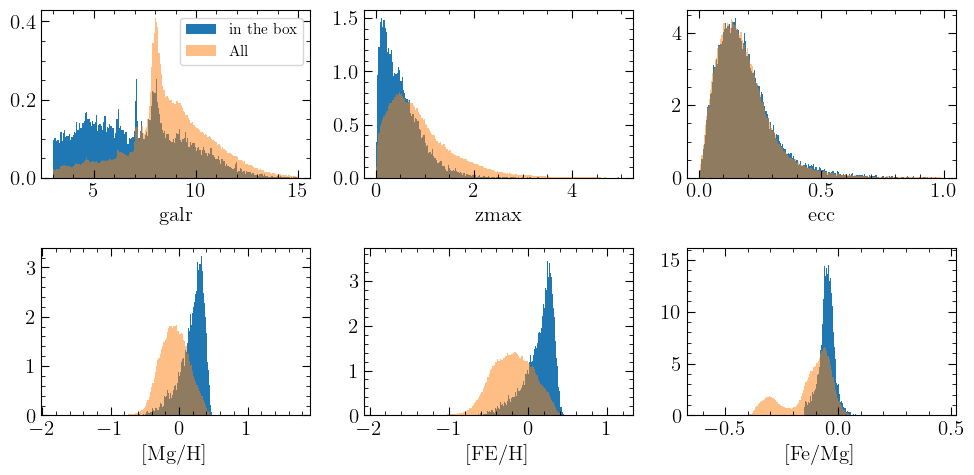

In [12]:
plt.figure(figsize=(10,5))
plt.subplot(2,3,1)
plt.hist(df_boxed['galr'], bins = 200, density=True, label = 'in the box')
plt.hist(data_all['galr'], bins=200, alpha = 0.5, density=True, label = 'All')
plt.xlabel('galr')
plt.legend(fontsize=11)

plt.subplot(2,3,2)
plt.hist(df_boxed['zmax'], bins = 200, density=True, label = 'in the box')
plt.hist(data_all['zmax'], bins=200, alpha = 0.5, density=True, label = 'All')
plt.xlabel('zmax')

plt.subplot(2,3,3)
plt.hist(df_boxed['e'], bins = 200, density=True, label = 'in the box')
plt.hist(data_all['e'], bins=200, alpha = 0.5, density=True, label = 'All')
plt.xlabel('ecc')


plt.subplot(2,3,4)
plt.hist(df_boxed['MG_H'], bins = 200, density=True, label = 'in the box')
plt.hist(data_all['MG_H'], bins=200, alpha = 0.5, density=True, label = 'All')
plt.xlabel('[Mg/H]')


plt.subplot(2,3,5)
plt.hist(df_boxed['FE_H'], bins = 200, density=True, label = 'in the box')
plt.hist(data_all['FE_H'], bins=200, alpha = 0.5, density=True, label = 'All')
plt.xlabel('[FE/H]')

plt.subplot(2,3,6)
plt.hist(df_boxed['FE_MG'], bins = 200, density=True, label = 'in the box')
plt.hist(data_all['FE_MG'], bins=200, alpha = 0.5, density=True, label = 'All')
plt.xlabel('[Fe/Mg]')


plt.tight_layout()

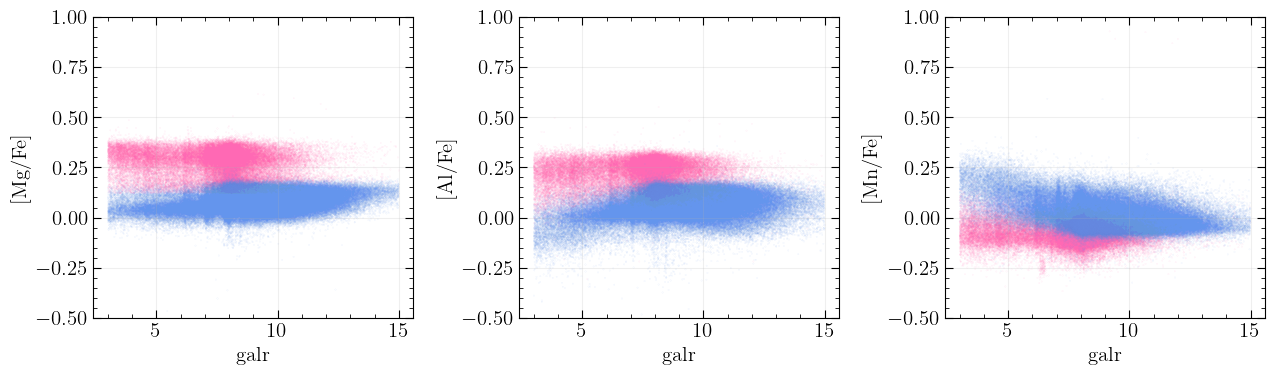

In [13]:
plt.figure(figsize=(13,4))

plt.subplot(1,3,1)
plt.scatter(data_all['galr'], data_all['MG_FE'], s = 0.001, color = data_all['color'])
plt.grid('True', alpha = 0.2)
plt.xlabel('galr')
plt.ylabel('[Mg/Fe]')
plt.ylim(-0.5,1)

plt.subplot(1,3,2)
data_all['AL_FE'] = data_all['AL_H'] - data_all['FE_H']
plt.scatter(data_all['galr'], data_all['AL_FE'], s = 0.001, color = data_all['color'])
plt.grid('True', alpha = 0.2)
plt.xlabel('galr')
plt.ylabel('[Al/Fe]')
plt.ylim(-0.5,1)

plt.subplot(1,3,3)
plt.scatter(data_all['galr'], data_all['MN_FE'], s = 0.001, color = data_all['color'])
plt.grid('True', alpha = 0.2)
plt.xlabel('galr')
plt.ylabel('[Mn/Fe]')
plt.ylim(-0.5,1)

plt.tight_layout()

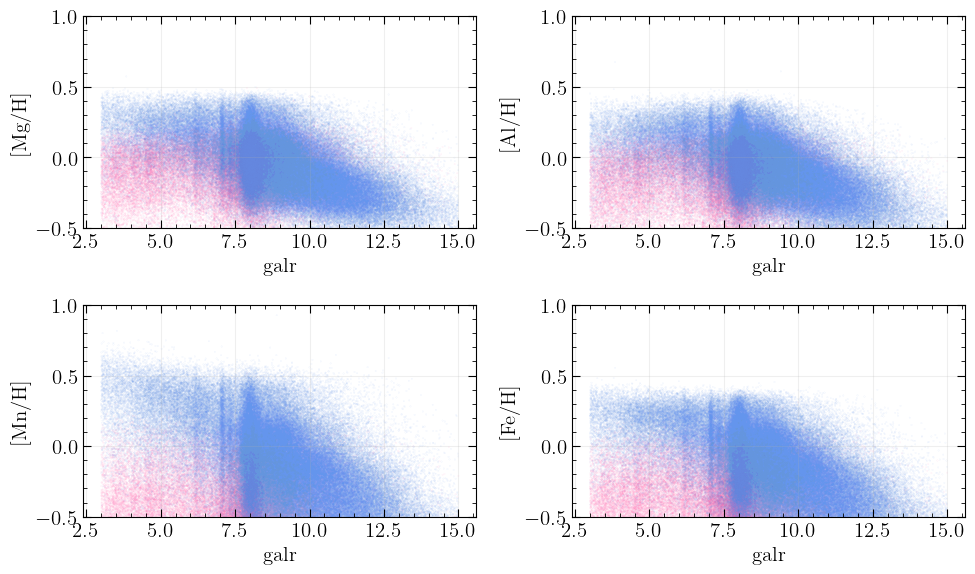

: 

: 

: 

In [ ]:
plt.figure(figsize=(10,6))

plt.subplot(2,2,1)
plt.scatter(data_all['galr'], data_all['MG_H'], s = 0.001, color = data_all['color'])
plt.grid('True', alpha = 0.2)
plt.xlabel('galr')
plt.ylabel('[Mg/H]')
plt.ylim(-0.5,1)

plt.subplot(2,2,2)
data_all['AL_FE'] = data_all['AL_H'] - data_all['FE_H']
plt.scatter(data_all['galr'], data_all['AL_H'], s = 0.001, color = data_all['color'])
plt.grid('True', alpha = 0.2)
plt.xlabel('galr')
plt.ylabel('[Al/H]')
plt.ylim(-0.5,1)

plt.subplot(2,2,3)
plt.scatter(data_all['galr'], data_all['MN_H'], s = 0.001, color = data_all['color'])
plt.grid('True', alpha = 0.2)
plt.xlabel('galr')
plt.ylabel('[Mn/H]')
plt.ylim(-0.5,1)

plt.subplot(2,2,4)
plt.scatter(data_all['galr'], data_all['FE_H'], s = 0.001, color = data_all['color'])
plt.grid('True', alpha = 0.2)
plt.xlabel('galr')
plt.ylabel('[Fe/H]')
plt.ylim(-0.5,1)

plt.tight_layout()

# Bin on [Mg/H]

In [14]:
mg_h_bin_edges = np.arange(-0.6, 0.3, 0.1) 
data_all['MG_H_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

# Downsampled

In [15]:
def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df

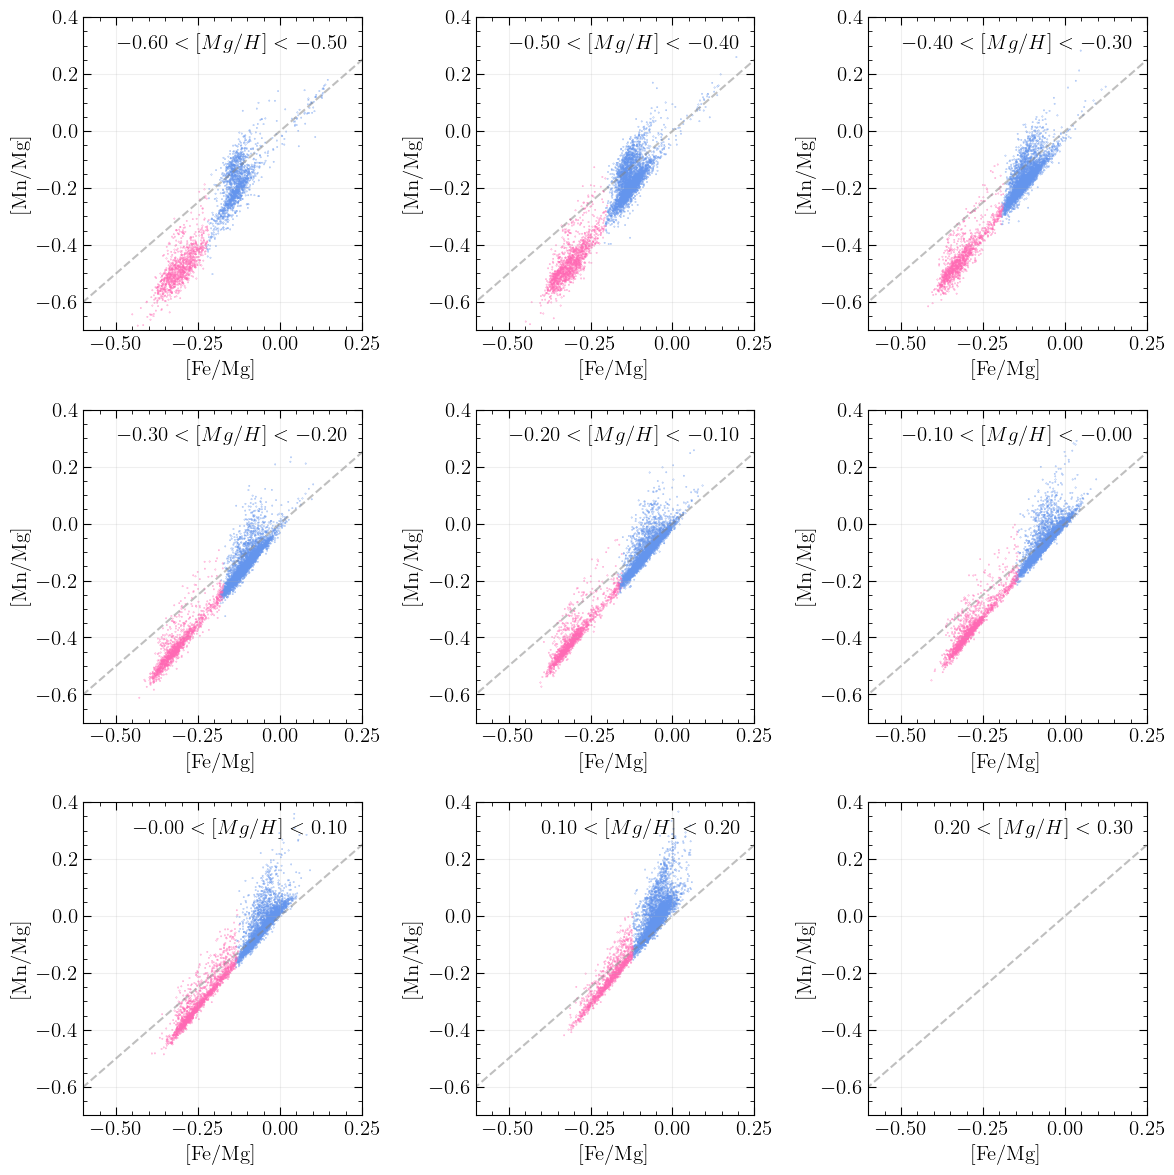

In [16]:
plt.figure(figsize=(12,12))

for i in range(len(mg_h_bin_edges)):
    df_to_plot = data_all[data_all['MG_H_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    plt.subplot(3,3,i+1)
    plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s = 0.05, color = df_to_plot['color'])
    plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
    label = rf'${mg_h_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_bin_edges[i] + 0.1):.2f}$'
    plt.text(0.95, 0.95, label, transform=plt.gca().transAxes, ha='right', va='top')
    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Fe/Mg]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-0.60,0.25)
    plt.ylim(-0.70,0.40)

plt.tight_layout()
#plt.savefig("/plots/high_low_alpha_MN_MG_FE_MG_down_sampled.png", dpi=300)

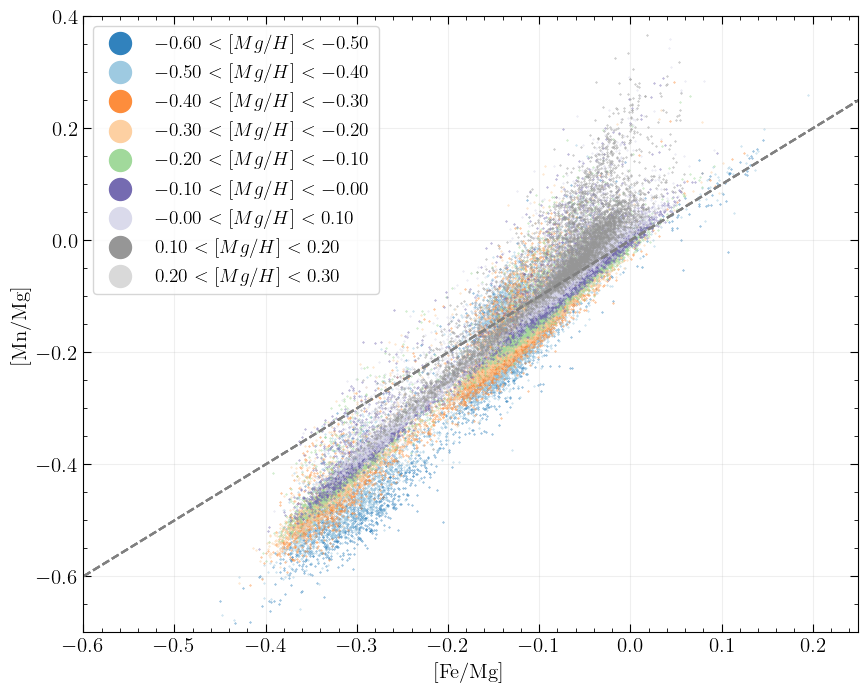

: 

: 

In [ ]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]

for i in range(len(mg_h_bin_edges)):
    df_to_plot = data_all[data_all['MG_H_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s = 0.1, color = colors[i], label = rf'${mg_h_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_bin_edges[i] + 0.1):.2f}$')
    plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Fe/Mg]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-0.60,0.25)
    plt.ylim(-0.70,0.40)

plt.legend(markerscale=50)

plt.savefig("plots/all_in_on_MN_MG_FE_MG_down_sampled.png", dpi=300)

# Bigger bins

In [17]:
mg_h_big_bin_edges = np.arange(-1.0, 1.0, 0.2) 
data_all['MG_H_big_bin'] = pd.cut(data_all['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)
colors_big_bins = ['brown', 'black', 'blue', 'green', 'hotpink', 'orange', 'red', 'turquoise', 'purple']

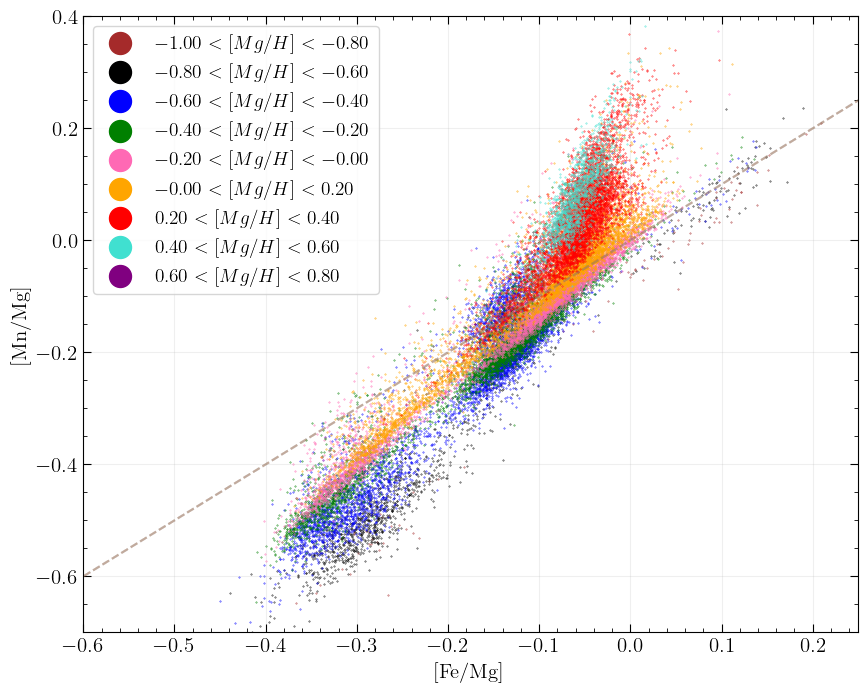

In [18]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]

for i in range(len(mg_h_big_bin_edges) - 1):
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
    plt.plot(xs, xs, alpha = 0.1, linestyle='--')
    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Fe/Mg]')
    plt.ylabel('[Mn/Mg]')
    plt.xlim(-0.60,0.25)
    plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=50)

plt.savefig("plots/all_in_on_MN_MG_FE_MG_down_sampled.png", dpi=300)

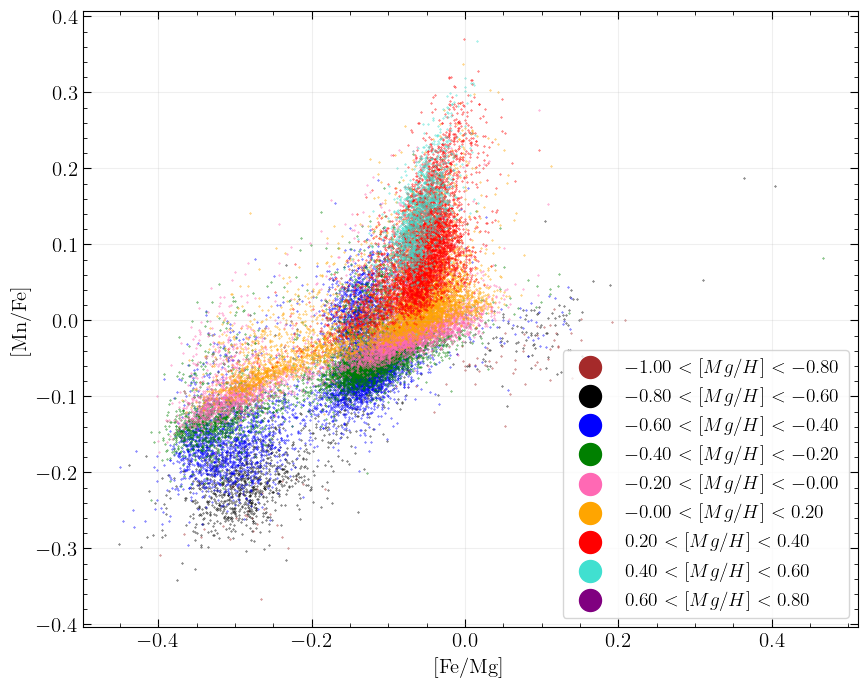

: 

: 

In [ ]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]

for i in range(len(mg_h_big_bin_edges) - 1):
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    plt.scatter(df_to_plot['FE_MG'], df_to_plot['MN_FE'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
    #plt.plot(xs, xs, alpha = 0.1, linestyle='--')
    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Fe/Mg]')
    plt.ylabel('[Mn/Fe]')
    #plt.xlim(-0.60,0.25)
    #plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=50)

plt.savefig("plots/all_in_on_MN_MG_FE_MG_down_sampled.png", dpi=300)

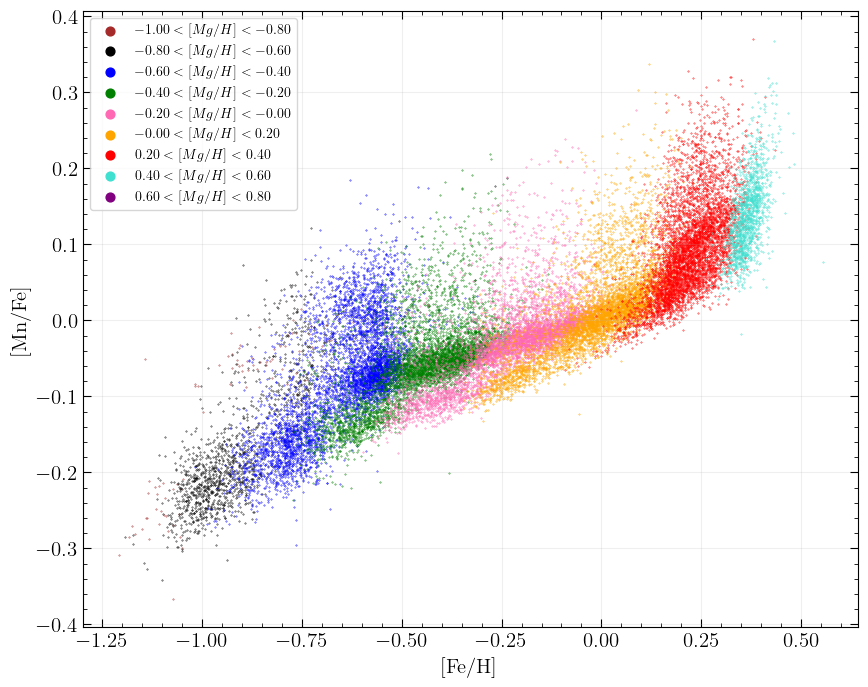

In [19]:
plt.figure(figsize=(10,8))
n_colors = 9   # since your original list had 9 colors
cmap = plt.get_cmap('tab20c')
colors = [cmap(i) for i in np.linspace(0, 1, n_colors)]

for i in range(len(mg_h_big_bin_edges) - 1):
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    plt.scatter(df_to_plot['FE_H'], df_to_plot['MN_FE'], s = 0.1, color = colors_big_bins[i], label = rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {(mg_h_big_bin_edges[i + 1]):.2f}$')
    #plt.plot(xs, xs, alpha = 0.1, linestyle='--')
    plt.grid('True', alpha = 0.2)
    plt.xlabel('[Fe/H]')
    plt.ylabel('[Mn/Fe]')
    #plt.xlim(-0.60,0.25)
    #plt.ylim(-0.70,0.40)

xs = np.linspace(-1, 1, 100)
#plt.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
plt.legend(markerscale=20, fontsize=10, loc = 'upper left')

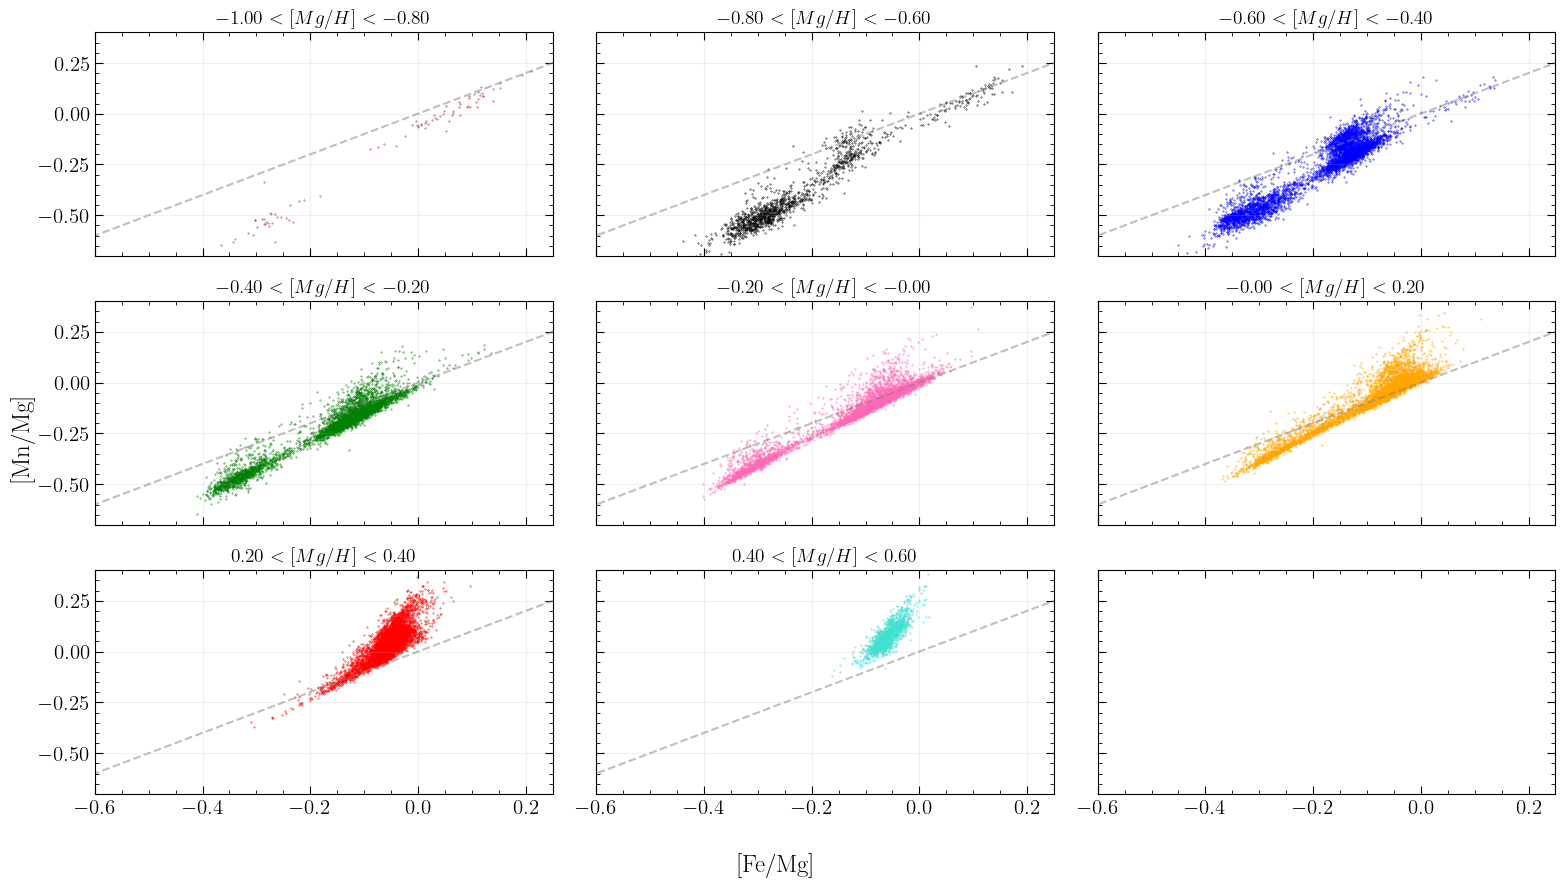

: 

: 

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)

    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'],
               s=0.1, color=colors_big_bins[i])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


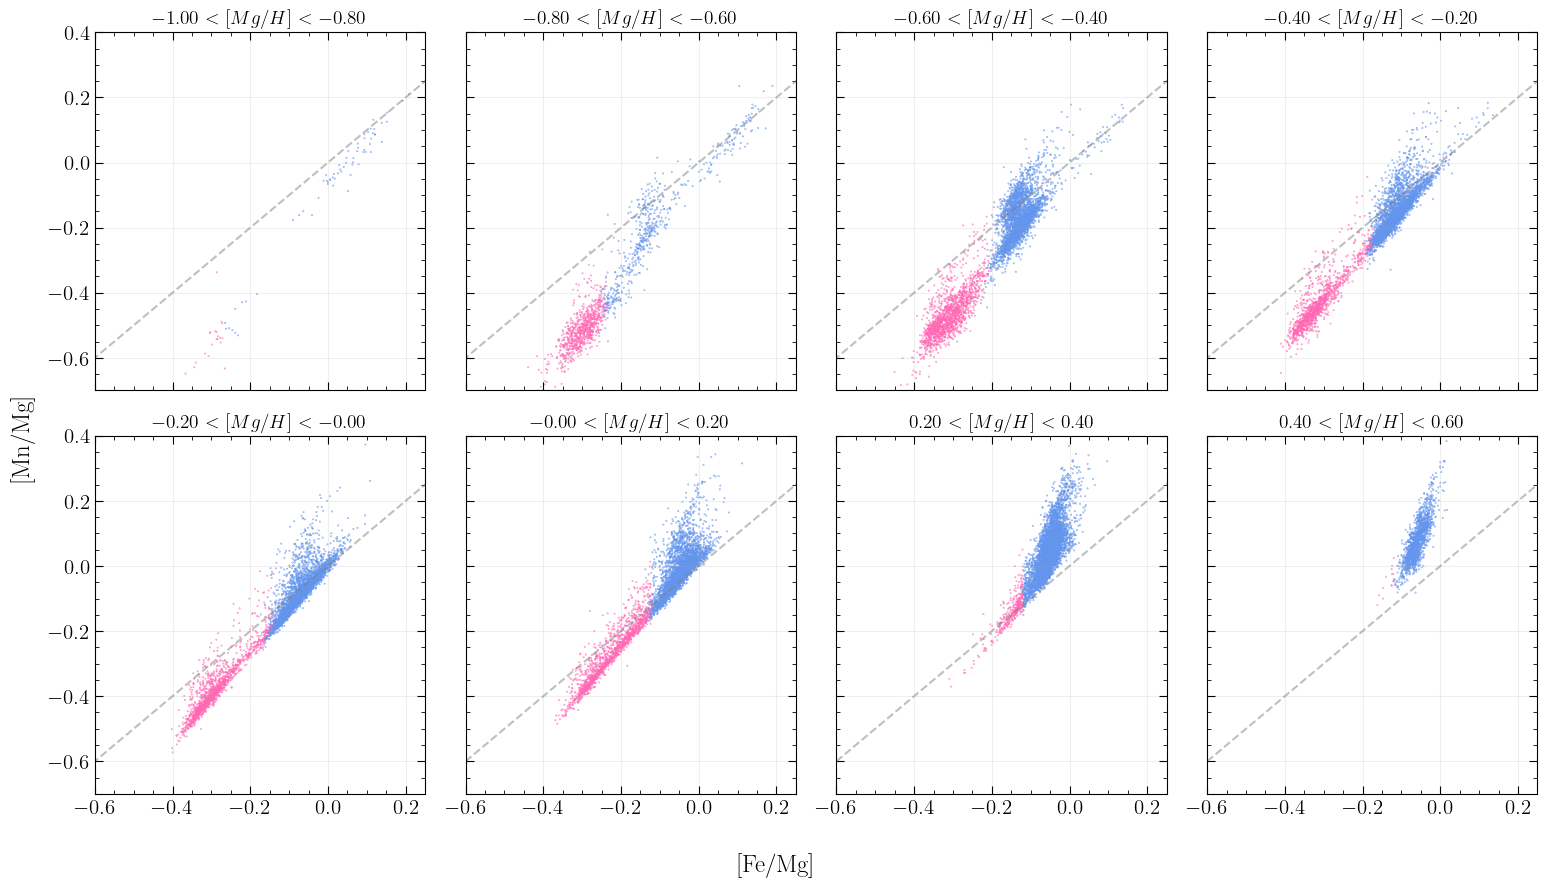

In [20]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)

    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'],
               s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


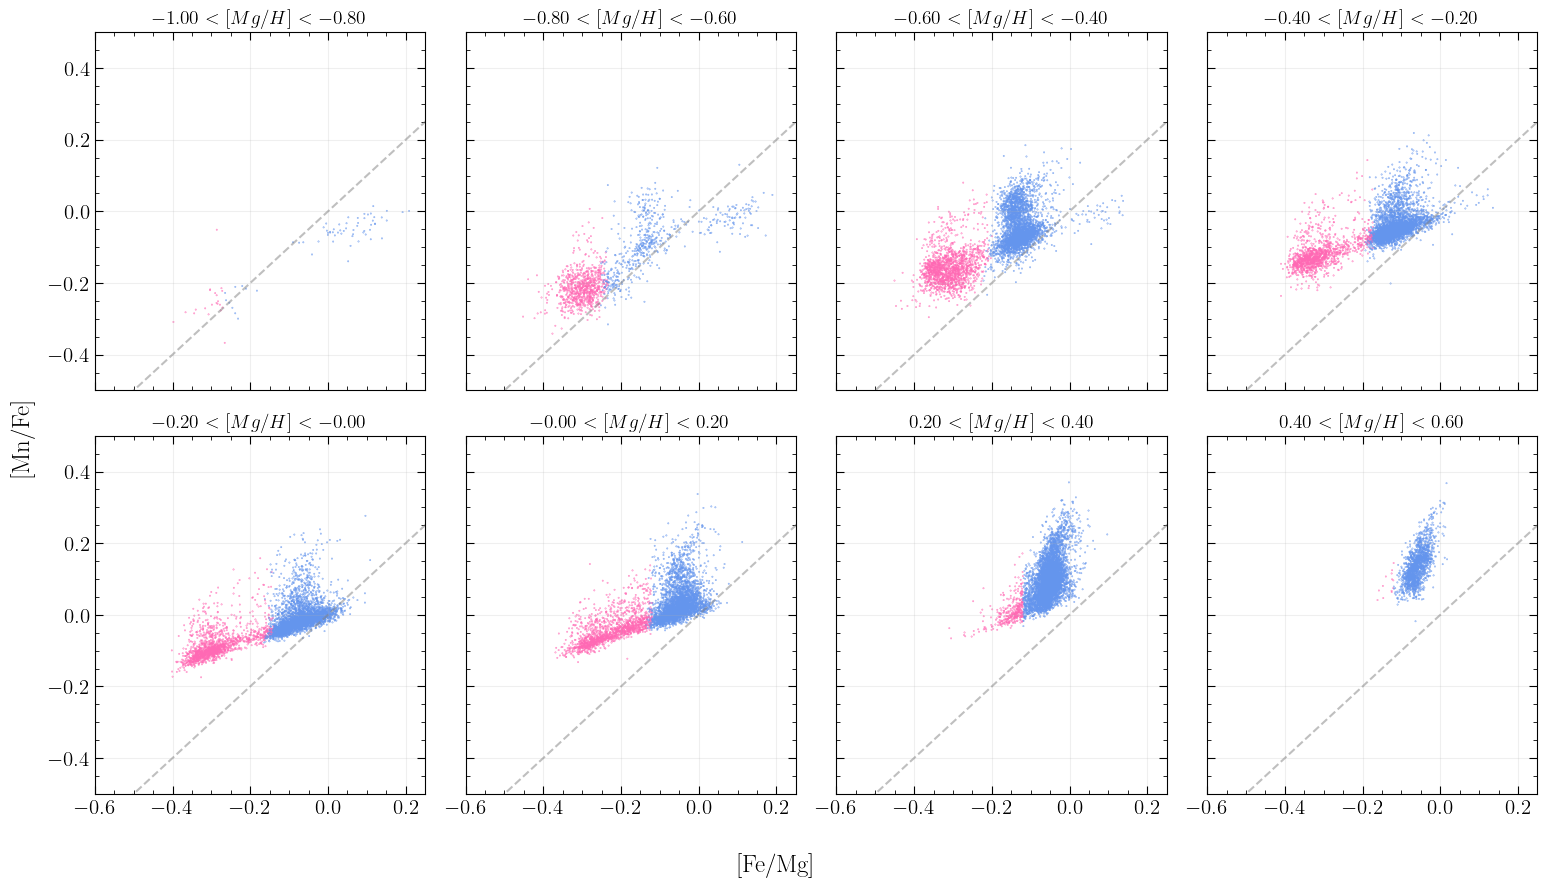

: 

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)

    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_FE'],
               s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.50, 0.50)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Fe]')
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


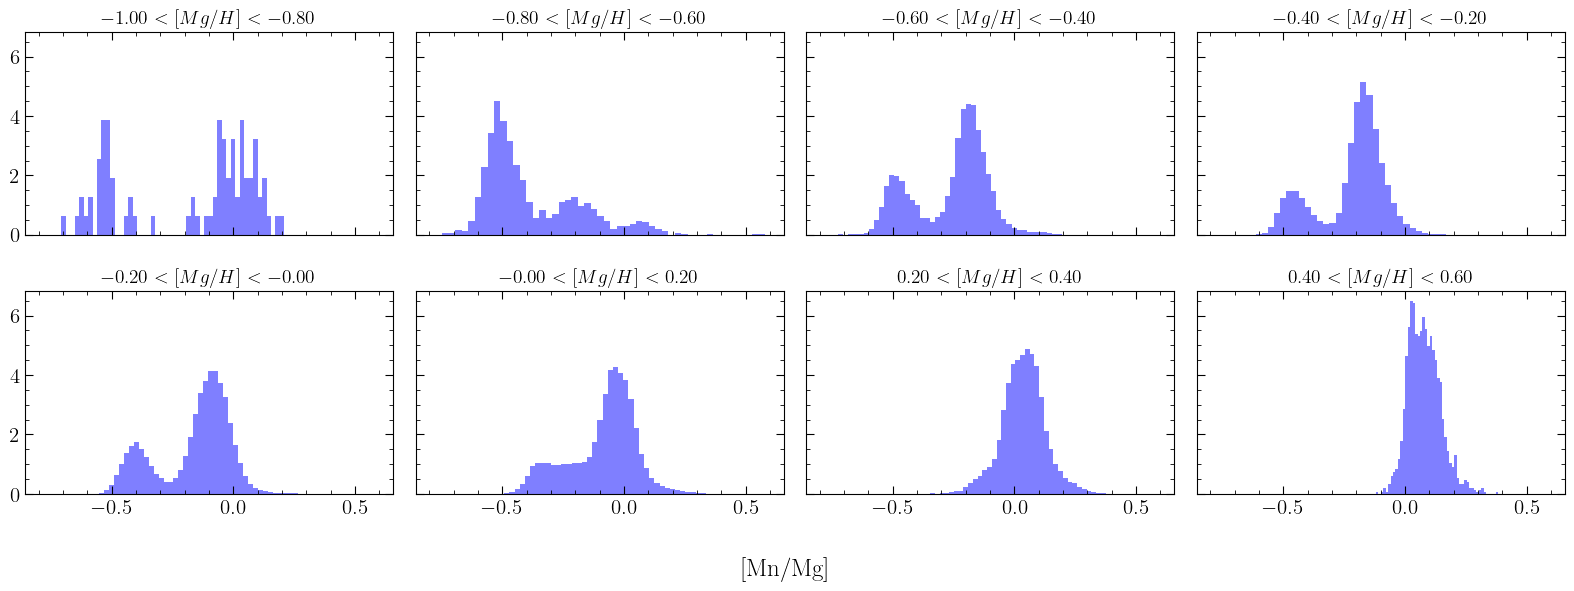

: 

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[(data_all['MG_H_big_bin'] == i)]
    #df_to_plot = downsample(df_to_plot, 5000)
    ax.hist(df_to_plot['MN_MG'], bins=50, density='True', color = 'blue', alpha = 0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i + 1]:.2f}$',
        fontsize=14
    )

fig.supxlabel('[Mn/Mg]')
plt.tight_layout()
plt.show()


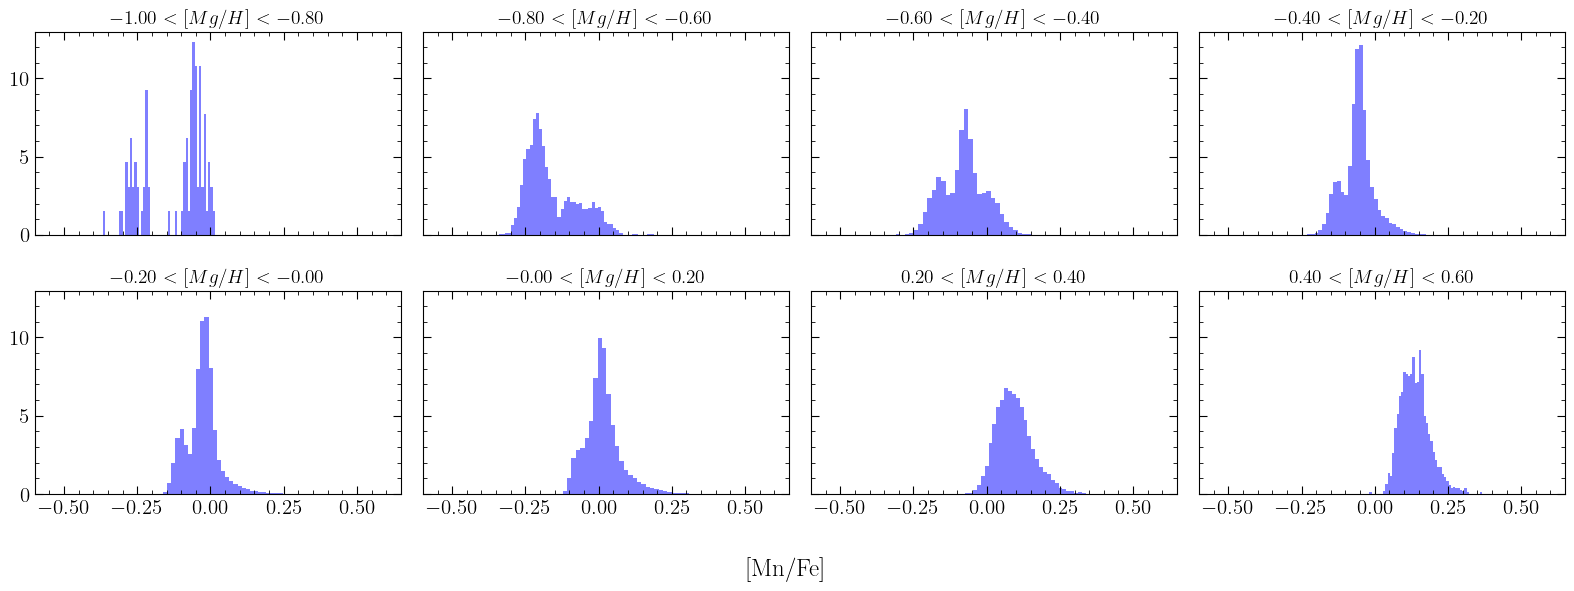

: 

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 6), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[(data_all['MG_H_big_bin'] == i)]
    #df_to_plot = downsample(df_to_plot, 5000)
    ax.hist(df_to_plot['MN_FE'], bins=50, density='True', color = 'blue', alpha = 0.5)

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i + 1]:.2f}$',
        fontsize=14
    )

fig.supxlabel('[Mn/Fe]')
plt.tight_layout()
plt.show()


# My models

# TAU*

In [21]:
m_g_array_const = np.ones(len(t_array))
etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
colors_lines = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']
colors_dots = ['greenyellow', 'cyan', 'orange', 'blue', 'red', 'yellow', 'green', 'gray', 'peru', 'navy']

tau_stars_2024 = [0.6, 2.0, 6.0]
etas_2024 = [0, 0.6, 1.0]

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask_1 = t_array > 6
sfr_1[mask_1] = 1e-10

sfrs = []
sfrs.append(sfr_1)
sfrs.append(sfr_2)
sfrs.append(sfr_3)


gals_taustar = []
gals_eta = []
gals_sfr = []


for i in range(len(tau_stars)):
    gals_taustar.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))

for j in range(len(etas)):
    gals_eta.append(evo.Galaxy(t_array=t_array, m_g_array=m_g_array_const, tau_star=1, eta=etas[j]))

for k in range(len(sfrs)):
    gals_sfr.append(evo.Galaxy(t_array=t_array, m_g_array=sfrs[k], tau_star=1, eta=0))

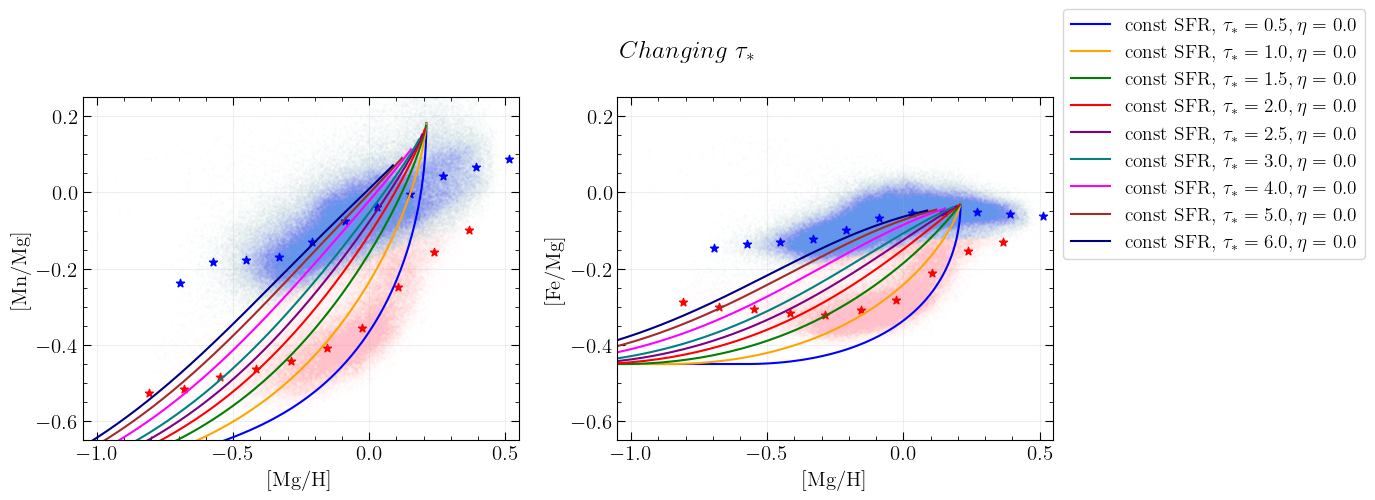

In [23]:
fig = plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar)):
    gal = gals_taustar[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle='-')
    #plt.plot(gal.O_H, gal.Fe_O, label = 'Fe', color = 'gray', alpha = 0.5, linestyle='--')
#plt.plot(gal1.O_H, gal1.Mn_O, label = rf'SFR1, $\tau_* = {gal1.tau_star_arr[0]} , \eta = {gal1.eta_arr[0]} $')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_taustar)):
    gal = gals_taustar[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i])


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.suptitle(r"$Changing \ \tau_*$")
plt.tight_layout()

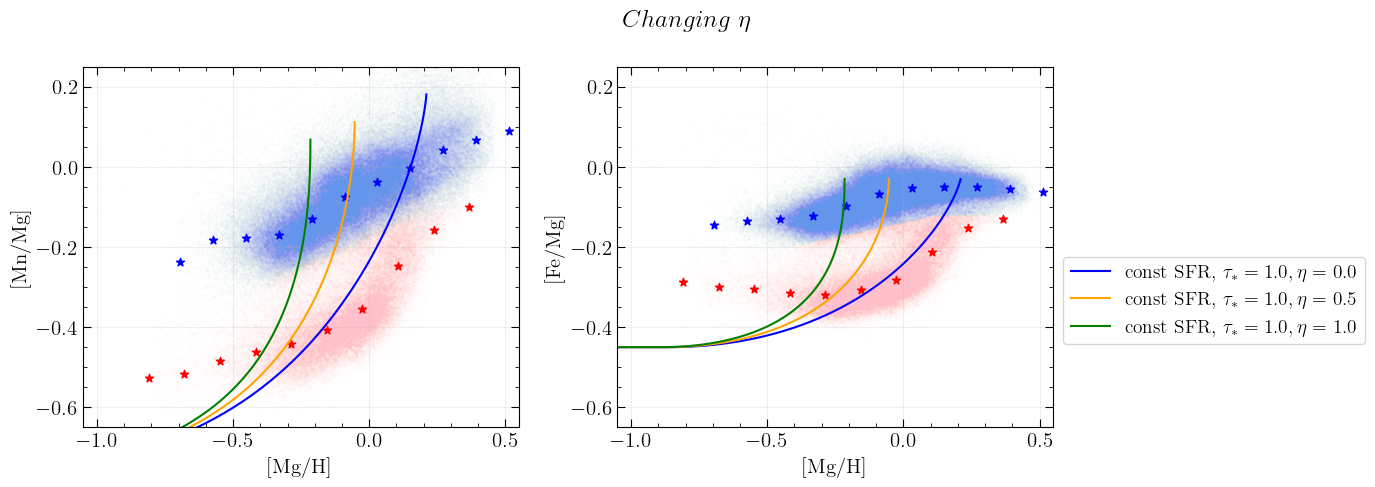

In [26]:
fig = plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_eta)):
    gal = gals_eta[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle='-')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_eta)):
    gal = gals_eta[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'const SFR, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i])


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.suptitle(r"$Changing \ \eta$")
plt.tight_layout()

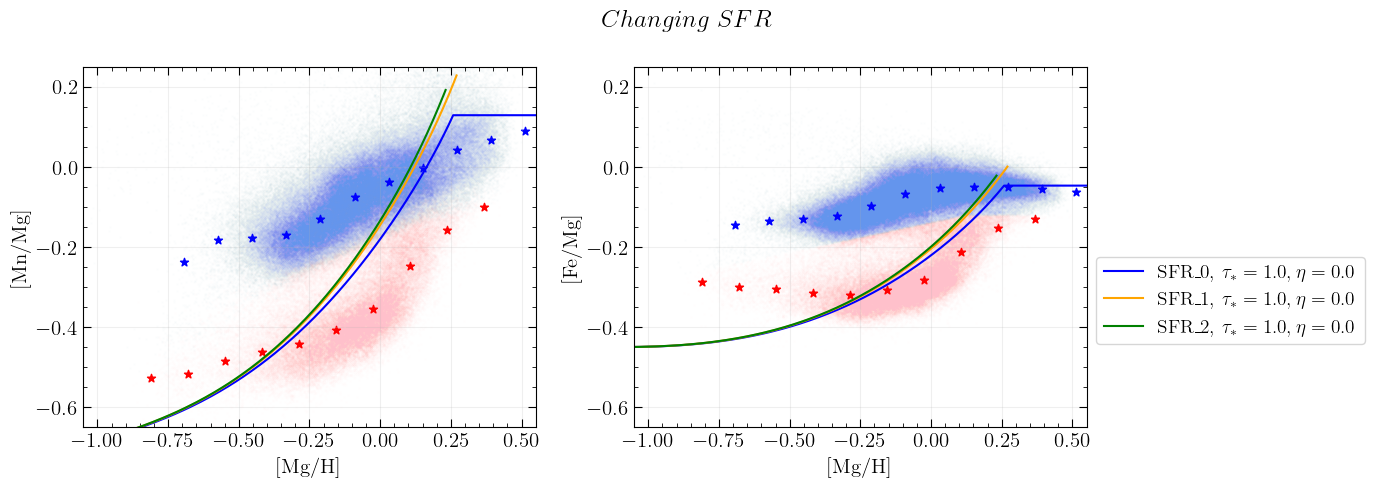

In [29]:
fig = plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(mnmg_low['x_center'], mnmg_low['MN_MG_median'], marker='*', color = 'blue')
plt.scatter(mnmg_high['x_center'], mnmg_high['MN_MG_median'], marker='*', color = 'red')

for i in range(len(gals_sfr)):
    gal = gals_sfr[i]
    plt.plot(gal.O_H, gal.Mn_O, label = 'Mn, default met dep', color = colors_lines[i], linestyle='-')



#fig.legend(loc="upper right", bbox_to_anchor=(0.5, 1.05), ncol=3)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['FE_MG'], alpha = 0.01, color = 'cornflowerblue', s = 0.5)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['FE_MG'], alpha = 0.01, color = 'pink', s = 0.5)
plt.scatter(femg_low['x_center'], femg_low['FE_MG_median'], marker='*', color = 'blue')
plt.scatter(femg_high['x_center'], femg_high['FE_MG_median'], marker='*', color = 'red')

for i in range(len(gals_sfr)):
    gal = gals_sfr[i]
    plt.plot(gal.O_H, gal.Fe_O, label = rf'SFR_{i}, $\tau_* = {gal.tau_star_arr[0]} , \eta = {gal.eta_arr[0]} $', color = colors_lines[i],)


plt.grid('True', alpha = 0.2)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.ylim(-0.65,0.25)
plt.xlim(-1.05,0.55)

plt.legend(bbox_to_anchor=[1, 0.5])

plt.suptitle(r"$Changing \ SFR$")
plt.tight_layout()

Text(0, 0.5, 'SFR')

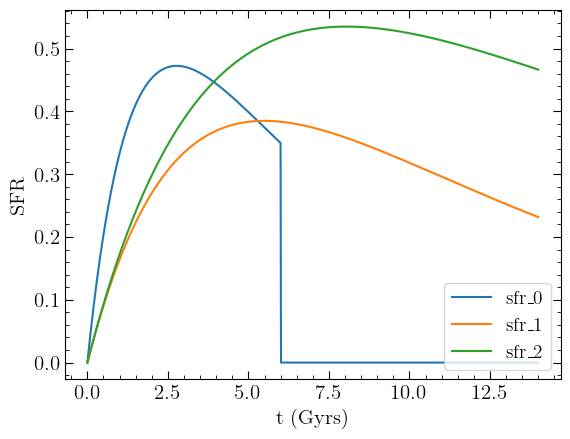

In [30]:
for i in range(len(sfrs)):
    plt.plot(t_array, sfrs[i], label = f'sfr_{i}')

plt.legend(loc = 'lower right')
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

In [31]:
mg_h_big_bin_centers = mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

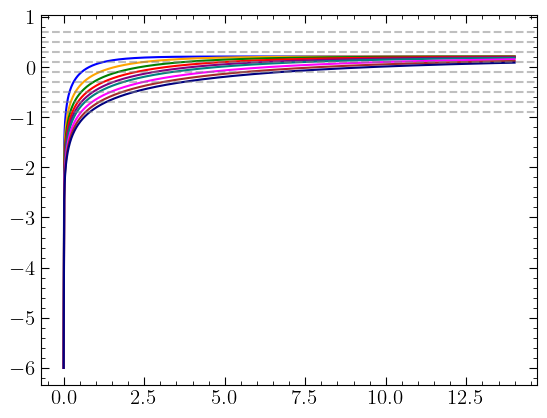

In [32]:
for i in range(len(gals_taustar)):
    gal = gals_taustar[i]
    plt.plot(gal.t, gal.O_H, label = 'Mn, default met dep', color = colors_lines[i], linestyle='-')

for i in range(len(mg_h_big_bin_centers)):
    plt.axhline(mg_h_big_bin_centers[i], alpha = 0.5, color = 'gray', linestyle = '--')

In [ ]:
"""
Old way of doing stuff

gals_end_points_taustar = []

for gal in gals_taustar:
    intersects = []
    for bin_cent in mg_h_big_bin_centers:
        idx = np.argmin(np.abs(gal.O_H - bin_cent))
        intersects.append(idx)

    intersects = np.array(intersects)
    gals_end_points_taustar.append(intersects)
"""
"""
gals_end_points_taustar = []

for gal in gals_taustar:
    gal_oh = np.asarray(gal.O_H)

    intersects = [
        idx for bin_cent in mg_h_big_bin_centers
        if (idx := np.searchsorted(gal_oh, bin_cent, side='left')) < len(gal_oh)
    ]

    gals_end_points_taustar.append(np.array(intersects, dtype=int))

gals_end_points_taustar
"""

[array([ 5,  8, 13, 22, 40, 89]),
 array([ 10,  16,  26,  44,  80, 178]),
 array([ 15,  24,  39,  66, 120, 267]),
 array([ 20,  32,  52,  88, 160, 356]),
 array([ 24,  39,  65, 110, 200, 445]),
 array([ 29,  47,  78, 132, 240, 534]),
 array([ 39,  63, 104, 176, 320, 713]),
 array([ 49,  79, 129, 220, 401, 891]),
 array([ 58,  94, 155, 264, 481])]

In [68]:
gals_end_points_taustar = []
for bin_cent in mg_h_big_bin_centers:
    end_points_in_this_bin = []
    for gal in gals_taustar:
        o_h = gal.O_H
        for indx in range(len(o_h)):
            o_h_at_time = o_h[indx]
            if o_h_at_time > bin_cent:
                end_points_in_this_bin.append(indx)
                break

    gals_end_points_taustar.append(np.array(end_points_in_this_bin))

In [69]:
#each array in gals_end_points_taustar is the end points for different galaxies in the same bin

gals_end_points_taustar[0]

array([ 5, 10, 15, 20, 24, 29, 39, 49, 58])

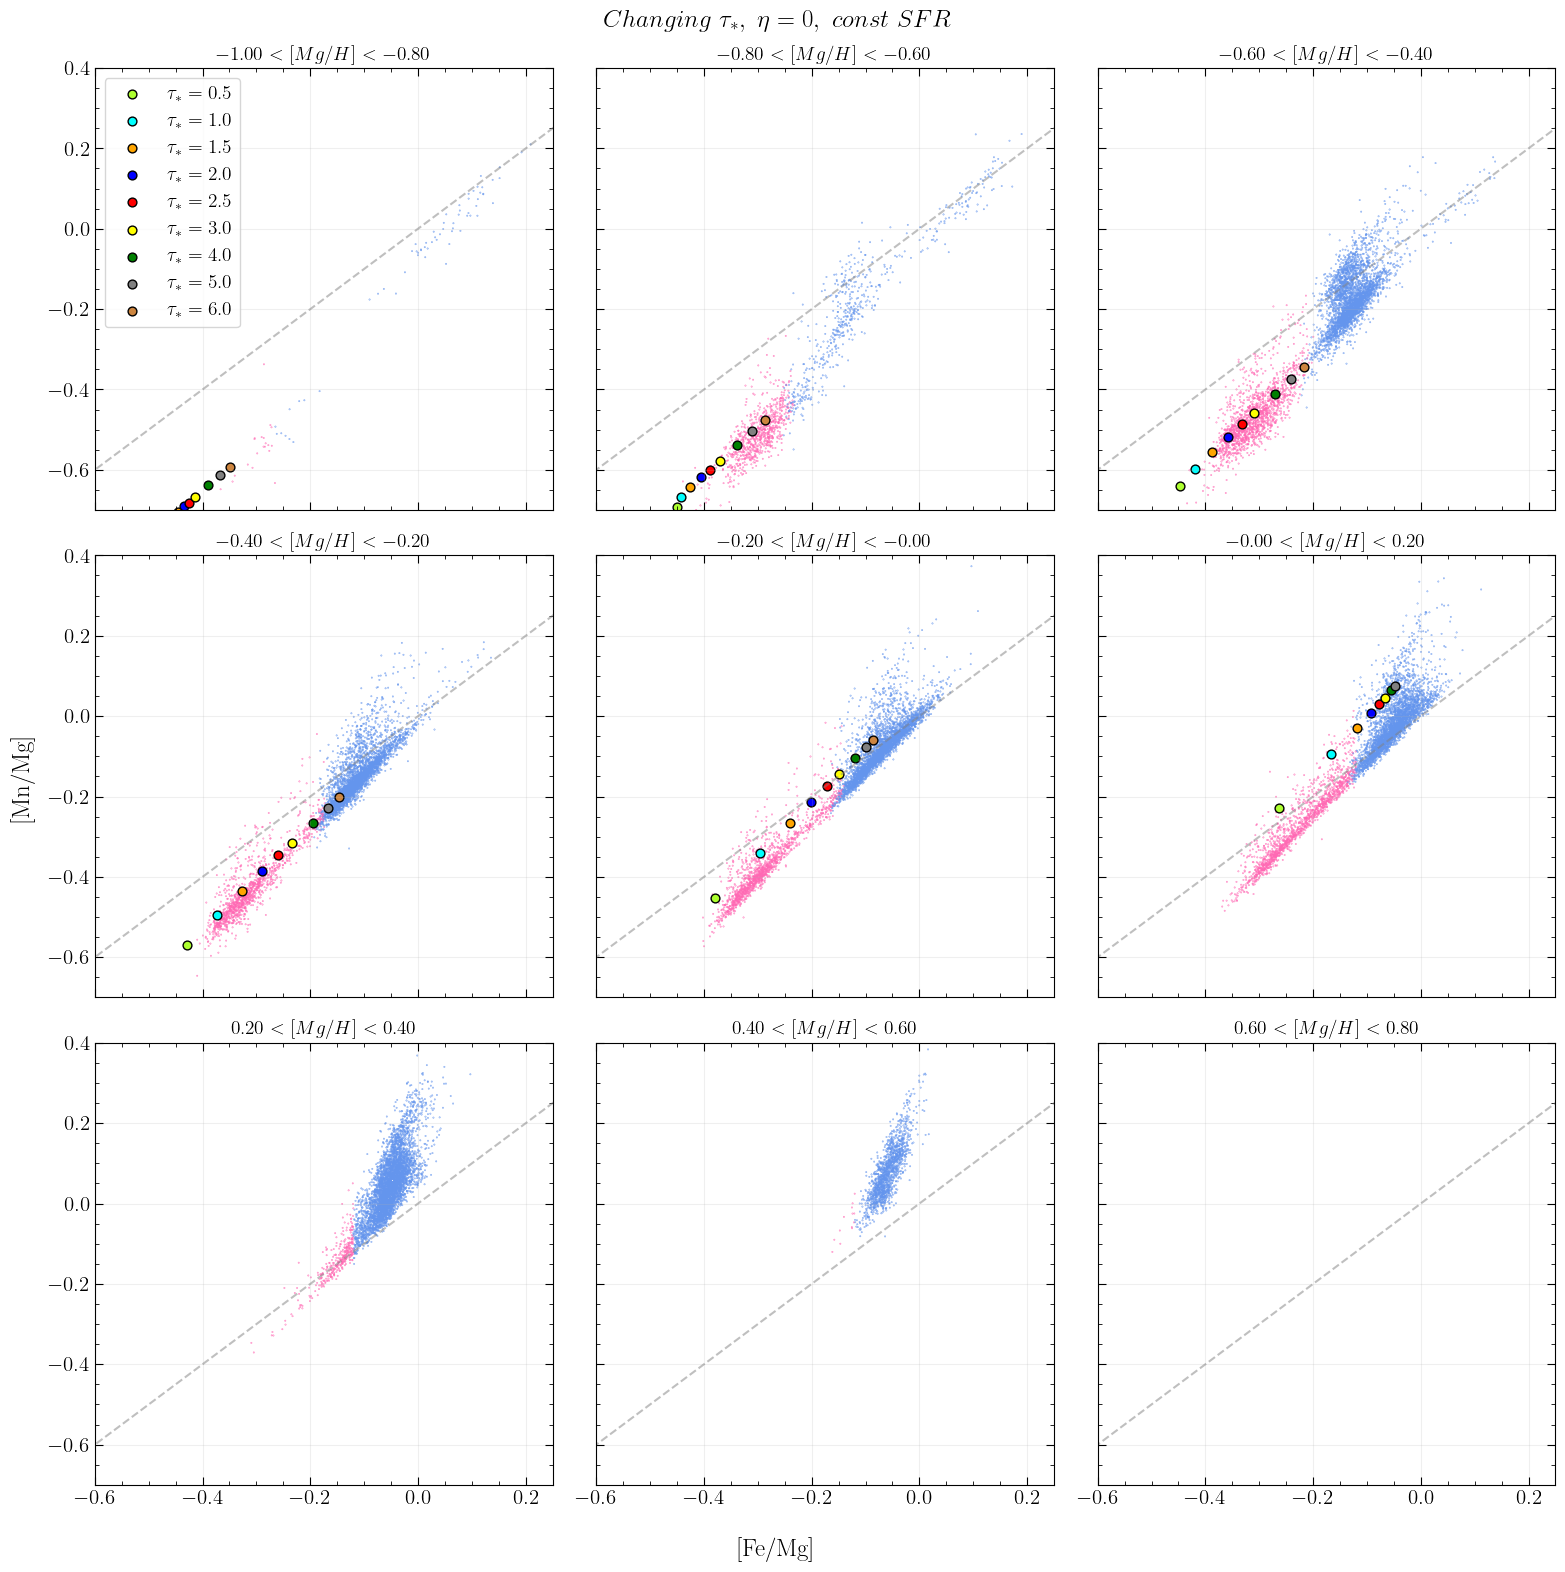

In [70]:
fig, axes = plt.subplots(3, 3, figsize=(16, 16), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(len(mg_h_big_bin_centers)):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)
    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    gal_end_points_this_bin = gals_end_points_taustar[i]
    for gal_n in range(len(gal_end_points_this_bin)):
        gal_temp = gals_taustar[gal_n]
        single_indx = gal_end_points_this_bin[gal_n] #indexes of the end points for galaxy n
        ax.scatter(gal_temp.Fe_Mg[single_indx], gal_temp.Mn_Mg[single_indx], s = 40, edgecolors='black', label = rf'$\tau_* = {gal_temp.tau_star_arr[0]}$',
                   color = colors_dots[gal_n])


    if i == 0:
        ax.legend()
    ax.set_title(rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',fontsize=14)

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(r"$Changing \ \tau_*, \ \eta = 0, \ const\ SFR$")
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


# eta

In [ ]:
gals_end_points_eta = []

for gal in gals_eta:
    intersects = []
    for bin_cent in mg_h_big_bin_centers:
        idx = np.argmin(np.abs(gal.O_H - bin_cent))
        intersects.append(idx)

    intersects = np.array(intersects)
    gals_end_points_eta.append(intersects)

: 

NameError: name 'gals_end_points_eta' is not defined

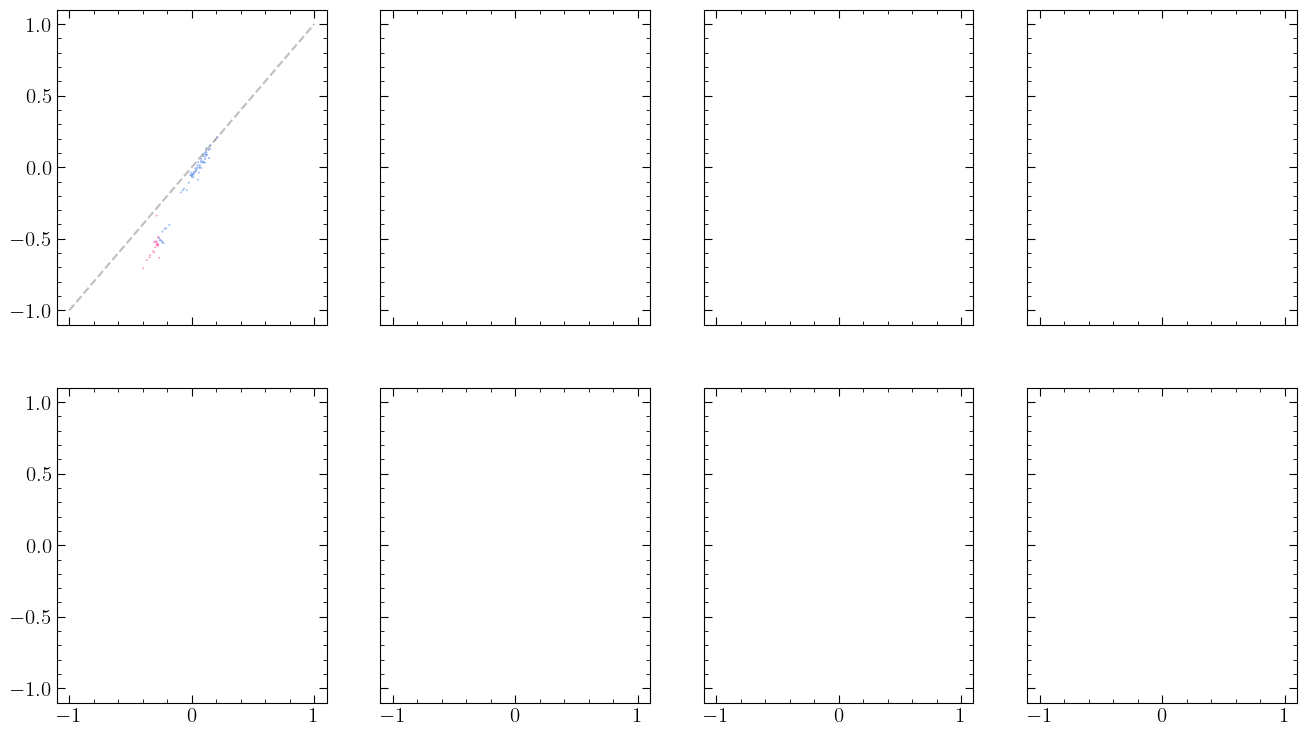

In [59]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)

    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
    for gal_n in range(len(gals_eta)):
        gal_indexes = gals_end_points_eta[gal_n] #indexes of the end points for galaxy n
        idx = gal_indexes[i] #i is the index for Mg/H bin
        gal_temp = gals_eta[gal_n]
        ax.scatter(gal_temp.Fe_Mg[idx], gal_temp.Mn_Mg[idx], s = 40, edgecolors='black', label = rf'$\eta = {gal_temp.eta_arr[0]}$',
                   color = colors_dots[gal_n])

    if i == 0:
        ax.legend()
    ax.set_title(rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',fontsize=14)

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(r"$Changing \ \eta, \ \tau_* = 1, \ const\ SFR$")
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


# SFR

In [ ]:
gals_end_points_sfr = []

for gal in gals_sfr:
    intersects = []
    for bin_cent in mg_h_big_bin_centers:
        idx = np.argmin(np.abs(gal.O_H - bin_cent))
        intersects.append(idx)

    intersects = np.array(intersects)
    gals_end_points_sfr.append(intersects)

: 

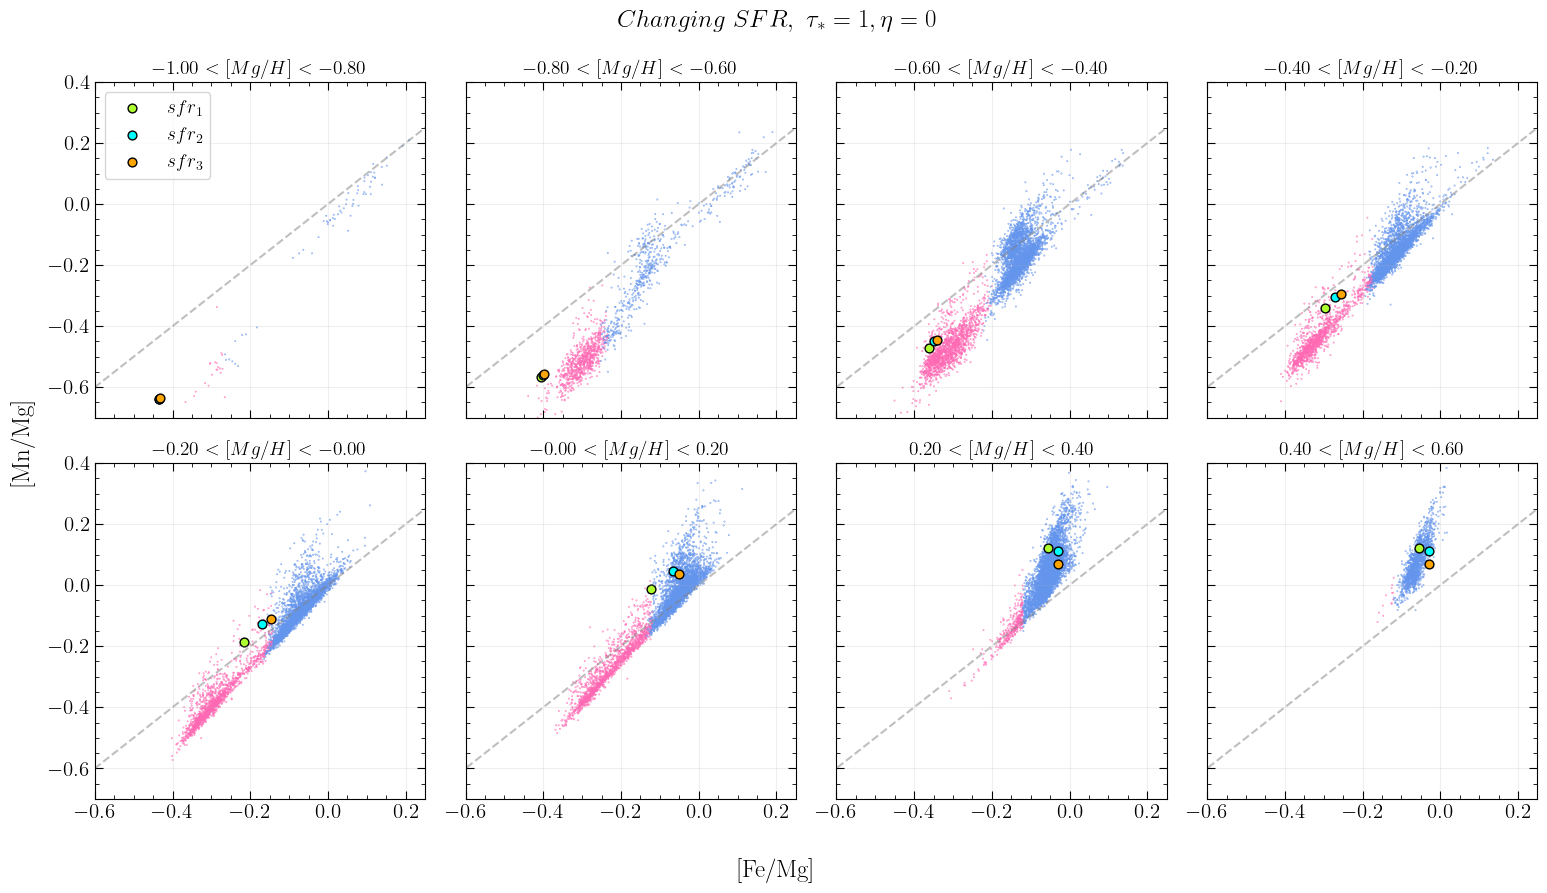

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = data_all[data_all['MG_H_big_bin'] == i]
    df_to_plot = downsample(df_to_plot, 5000)

    ax.scatter(df_to_plot['FE_MG'], df_to_plot['MN_MG'], s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')
    for gal_n in range(len(gals_sfr)):
        gal_indexes = gals_end_points_sfr[gal_n] #indexes of the end points for galaxy n
        idx = gal_indexes[i] #i is the index for Mg/H bin
        gal_temp = gals_eta[gal_n]
        ax.scatter(gal_temp.Fe_Mg[idx], gal_temp.Mn_Mg[idx], s = 40, edgecolors='black', label = rf'$sfr_{gal_n+1}$',
                   color = colors_dots[gal_n])

    if i == 0:
        ax.legend()
    ax.set_title(rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',fontsize=14)

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/Mg]')
fig.supylabel('[Mn/Mg]')
fig.suptitle(r"$Changing \ SFR, \ \tau_* = 1, \eta = 0$")
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


# Mock stars

In [ ]:
mock_stars = pd.read_csv("../Dec3 meeting/all_mock_stars.csv")

boundary_mgfe = np.where(
    mock_stars['Fe_H'] < 0,
    0.12 - 0.13 * mock_stars['Fe_H'],  # negative metallicity
    0.12                                   # positive metallicity
)

# Now you can compare safely
mask_high = mock_stars['O_Fe'] > boundary_mgfe
mock_highalphas = mock_stars[mask_high]
mock_lowalphas = mock_stars[~mask_high]

mock_lowalphas['color'] = 'cornflowerblue'
mock_highalphas['color'] = 'hotpink'

mock_all = pd.concat([mock_highalphas, mock_lowalphas], ignore_index=True)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_99897/129081420.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mock_lowalphas['color'] = 'cornflowerblue'
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_99897/129081420.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  mock_highalphas['color'] = 'hotpink'


: 

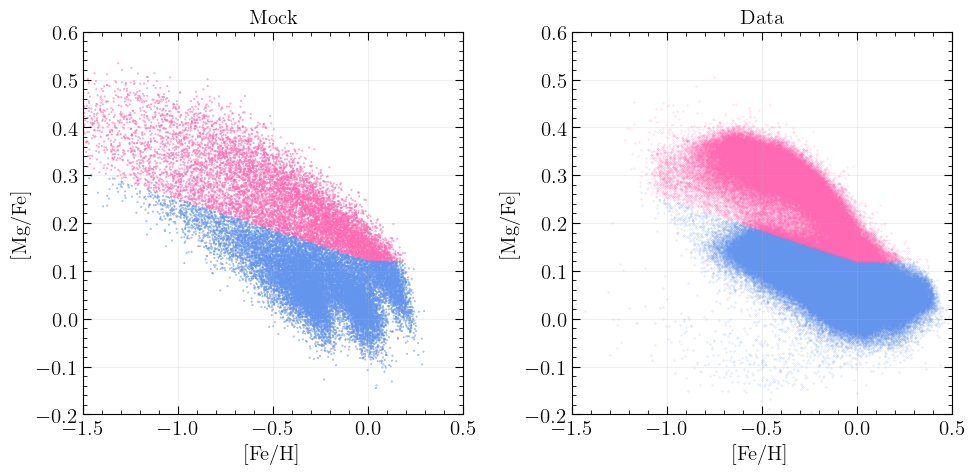

: 

In [ ]:
fig = plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(mock_all['Fe_H'], mock_all['O_Fe'], s = 0.1, color = mock_all['color'])

plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.ylim(-0.2,0.6)
plt.xlim(-1.5,0.5)
plt.title("Mock")


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['FE_H'], data_low_alpha['MG_FE'], alpha = 0.5, color = 'cornflowerblue', s = 0.05)
plt.scatter(data_high_alpha['FE_H'], data_high_alpha['MG_FE'], alpha = 0.5, color = 'hotpink', s = 0.05)
plt.grid('True', alpha = 0.2)
plt.xlabel('[Fe/H]')
plt.ylabel('[Mg/Fe]')
plt.ylim(-0.2,0.6)
plt.xlim(-1.5,0.5)
plt.title("Data")

plt.tight_layout()

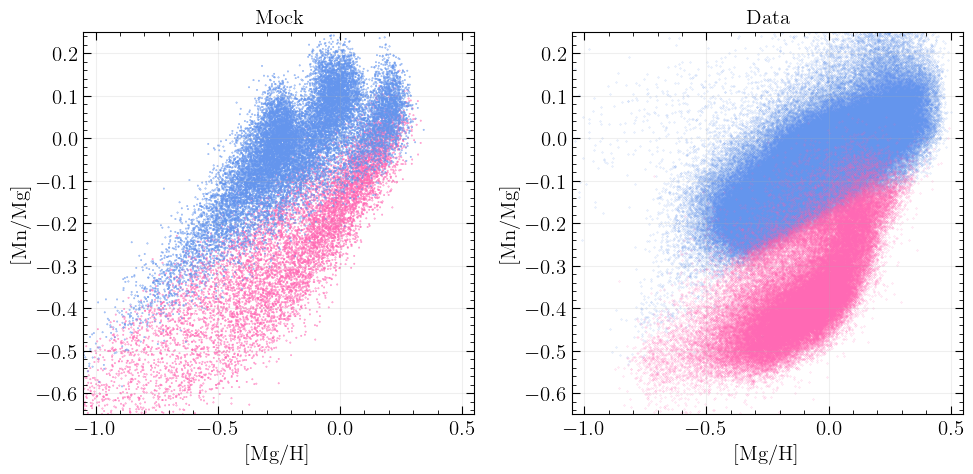

: 

In [ ]:
fig = plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.scatter(mock_all['O_H'], mock_all['Mn_O'], s = 0.1, color = mock_all['color'])
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.title("Mock")


plt.subplot(1,2,2)
plt.scatter(data_low_alpha['MG_H'], data_low_alpha['MN_MG'], alpha = 0.5, color = 'cornflowerblue', s = 0.05)
plt.scatter(data_high_alpha['MG_H'], data_high_alpha['MN_MG'], alpha = 0.5, color = 'hotpink', s = 0.05)
plt.grid('True', alpha = 0.2)
plt.ylim(-0.65,0.25)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.xlim(-1.05,0.55)
plt.title("Data")


plt.tight_layout()

In [ ]:
mock_all

,O_H,Fe_O,Mn_O,O_Fe,Fe_H,Mn_H,color
0,0.011510,-0.233433,-0.228801,0.233433,-0.221923,-0.217291,hotpink
1,0.165682,-0.236942,-0.130766,0.236942,-0.071260,0.034916,hotpink
2,0.145796,-0.191373,0.015233,0.191373,-0.045577,0.161029,hotpink
3,0.244120,-0.121131,0.158577,0.121131,0.122989,0.402697,hotpink
4,-0.155033,-0.328717,-0.327932,0.328717,-0.483751,-0.482966,hotpink
...,...,...,...,...,...,...,...
26995,-0.467806,-0.036195,-0.073783,0.036195,-0.504001,-0.541590,cornflowerblue
26996,-0.363603,-0.077284,-0.117601,0.077284,-0.440887,-0.481204,cornflowerblue
26997,-0.305648,-0.068497,-0.034354,0.068497,-0.374145,-0.340002,cornflowerblue
26998,-0.369428,-0.041228,-0.067229,0.041228,-0.410656,-0.436657,cornflowerblue


: 

(array([2.15322160e-05, 2.47620402e-04, 1.75487502e-03, 1.22765930e-01,
        1.36303234e+00, 1.20562027e+00, 9.93819429e-02, 0.00000000e+00,
        0.00000000e+00, 5.38305400e-05]),
 array([-1.841187  , -1.48313355, -1.12507999, -0.76702642, -0.40897298,
        -0.05091953,  0.30713415,  0.6651876 ,  1.02324104,  1.38129449,
         1.73934793]),
 <BarContainer object of 10 artists>)

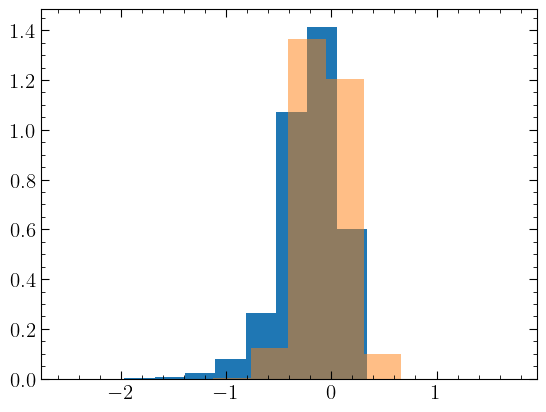

: 

In [ ]:
plt.hist(mock_all['O_H'], density=True)
plt.hist(data_all['MG_H'], alpha = 0.5, density=True)

In [ ]:
o_h_big_bin_edges = mg_h_big_bin_edges
o_h_big_bin_centers = mg_h_big_bin_centers
mock_all['O_H_big_bin'] = pd.cut(mock_all['O_H'], bins = o_h_big_bin_edges, right=False, labels=False)

: 

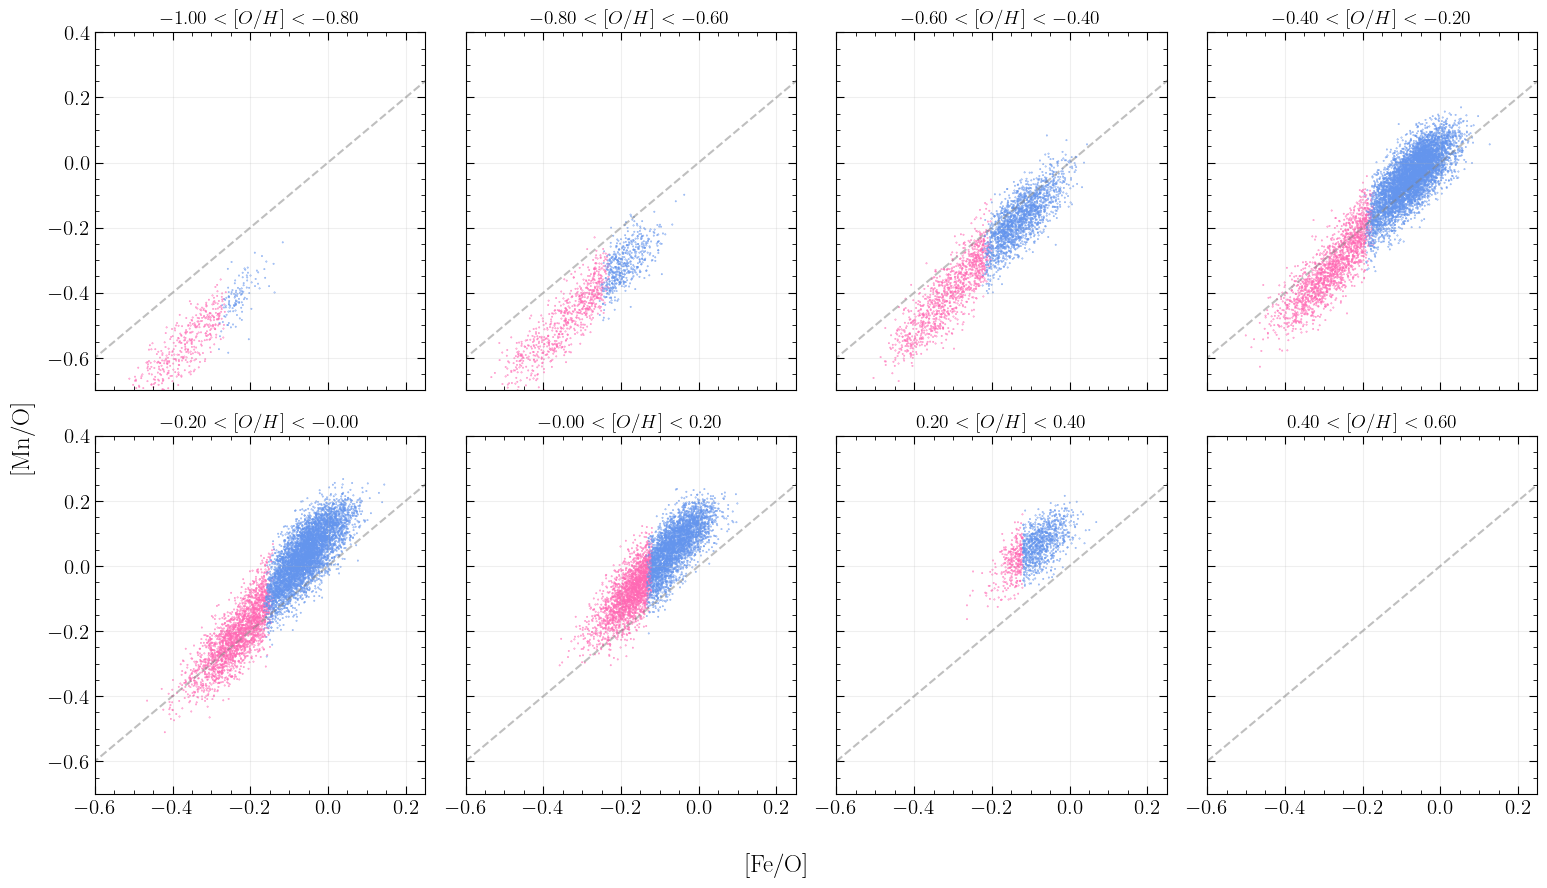

: 

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 9), sharex=True, sharey=True)
axes = axes.flatten()

for i in range(8):
    ax = axes[i]
    df_to_plot = mock_all[mock_all['O_H_big_bin'] == i]
    #df_to_plot = downsample(df_to_plot, 5000)

    ax.scatter(df_to_plot['Fe_O'], df_to_plot['Mn_O'],
               s=0.1, color=df_to_plot['color'])
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, linestyle = '--', alpha = 0.5, color = 'gray')

    ax.set_title(
        rf'${o_h_big_bin_edges[i]:.2f} < [O/H] < {o_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

fig.supxlabel('[Fe/O]')
fig.supylabel('[Mn/O]')
plt.tight_layout()
#plt.savefig("plots/MN_MG_vs_FE_MG_subplots_big_bins_black_blue.png", dpi=300)
plt.show()


: 